# TECA2 — Atividade 4 · 1ª Parte (pipeline clássico)
**Visão Computacional (TECA2 20261) · UFG · 2026/1** — Grupo: Henryque Oliveira

Notebook do pipeline clássico de inspeção. Roda ponta-a-ponta no Colab
(`!pip install` no bootstrap) e localmente com `uv`. Seeds fixas (=42) para
reprodutibilidade.

## Bootstrap — dependências, caminhos e seeds

In [1]:
import sys, os, subprocess

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _in_colab():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy", "opencv-python", "matplotlib", "scipy",
                    "scikit-image", "scikit-learn"], check=True)

# Localiza a raiz do projeto (a que contém src/ e data/)
_cands = [".", "..", os.getcwd(), "/content/teca2-atividade4"]
ROOT = next((p for p in _cands
             if os.path.isdir(os.path.join(p, "src"))
             and os.path.isdir(os.path.join(p, "data"))), None)
assert ROOT, "Raiz do projeto (src/ + data/) não encontrada — ajuste ROOT."
ROOT = os.path.abspath(ROOT)
sys.path.insert(0, ROOT)
DATA = os.path.join(ROOT, "data")
RESULTS = os.path.join(ROOT, "results"); os.makedirs(RESULTS, exist_ok=True)

import random, numpy as np
SEED = 42
random.seed(SEED); np.random.seed(SEED)

import cv2, matplotlib
import matplotlib.pyplot as plt
print("ROOT =", ROOT)
print("numpy", np.__version__, "| opencv", cv2.__version__)

ROOT = /home/henryque/Documents/JOB/recognition-cvis
numpy 2.5.0 | opencv 4.13.0


---
## Bloco 2 — Segmentação + rotulação

**Objetivo (CLAUDE.md §4.2):** Otsu *próprio* sobre `cenas_cinza`, comparar com
`cenas_bin`; morfologia mínima (Cap. 9); `connectedComponentsWithStats`.

**Critério de aceite:** label map colorido; *nº de componentes ≈ objetos visíveis.*

Toda a lógica vive em [`src/segmentacao.py`](../src/segmentacao.py). O limiar de
Otsu é implementado na mão (histograma + somas cumulativas da variância
entre-classes); `cv2.threshold(..., THRESH_OTSU)` entra **só como validação**.

In [2]:
import json
from src import segmentacao as seg

Z = np.load(os.path.join(DATA, "cenas_esteira.npz"), allow_pickle=True)
cenas_cinza = Z["cenas_cinza"]      # (10, 200, 800) uint8
cenas_bin   = Z["cenas_bin"]        # (10, 200, 800) uint8  — Otsu de referência
META = json.load(open(os.path.join(DATA, "metadados_cenas.json")))
N_CENAS = cenas_cinza.shape[0]
print(f"{N_CENAS} cenas de {cenas_cinza.shape[1]}x{cenas_cinza.shape[2]} px")

10 cenas de 200x800 px


### 2.1 — Otsu DO ZERO vs `cv2` (validação cruzada)

Validação 1: o limiar calculado na mão tem de coincidir com o do OpenCV.
Validação 2: a binarização resultante tem de bater com `cenas_bin`
(acurácia de pixel, IoU, Dice).

In [3]:
print(f"{'cena':>4} {'t_meu':>6} {'t_cv2':>6} {'acc_px':>8} {'IoU':>7} {'Dice':>7}")
res = []
accs, ious = [], []
for i in range(N_CENAS):
    g = cenas_cinza[i]
    t_cv, _ = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    r = seg.segmentar_cena(g, abertura=3, area_min=0)
    conc = seg.concordancia(r["mask_morf"], cenas_bin[i])
    res.append(r); accs.append(conc["acuracia_px"]); ious.append(conc["iou"])
    print(f"{i:>4} {r['limiar']:>6} {int(t_cv):>6} {conc['acuracia_px']*100:>7.2f}% "
          f"{conc['iou']:>7.3f} {conc['dice']:>7.3f}")

assert all(r["limiar"] == int(cv2.threshold(cenas_cinza[i],0,255,
           cv2.THRESH_BINARY+cv2.THRESH_OTSU)[0]) for i, r in enumerate(res)), \
       "limiar próprio divergiu do cv2!"
print(f"\n✔ Otsu próprio == cv2 em todas as cenas. "
      f"Acurácia de pixel média {np.mean(accs)*100:.2f}% | IoU médio {np.mean(ious):.3f}")

cena  t_meu  t_cv2   acc_px     IoU    Dice
   0    112    112   99.99%   0.997   0.999
   1    112    112   99.99%   0.996   0.998
   2    112    112   99.98%   0.995   0.998
   3    112    112   99.99%   0.997   0.998
   4    112    112   99.99%   0.997   0.999
   5    112    112   99.99%   0.997   0.998
   6    112    112   99.98%   0.996   0.998
   7    112    112   99.98%   0.997   0.998
   8    112    112   99.98%   0.996   0.998
   9    112    112   99.99%   0.997   0.999

✔ Otsu próprio == cv2 em todas as cenas. Acurácia de pixel média 99.99% | IoU médio 0.997


### 2.2 — Pipeline em camadas (uma cena)

Visualização dos estágios: cinza → Otsu próprio → diferença vs referência →
morfologia → mapa de rótulos colorido.

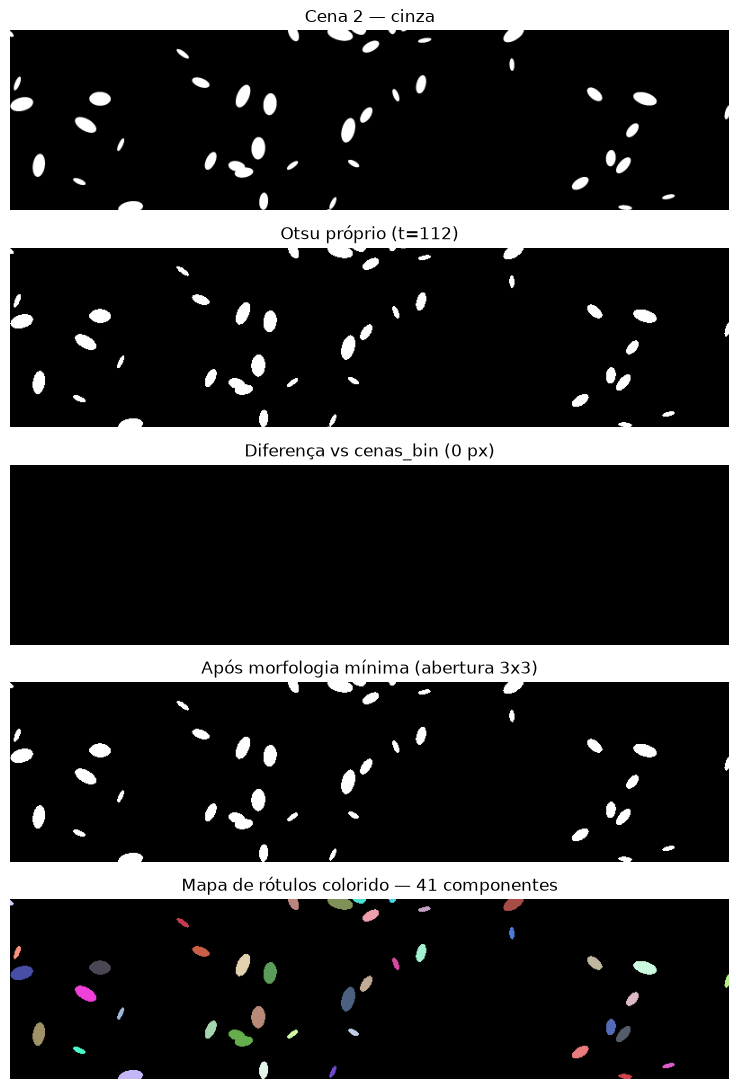

In [4]:
ci = 2  # cena de exemplo
g = cenas_cinza[ci]; r = res[ci]
diff = (((r["mask_bin"] > 0) != (cenas_bin[ci] > 0)).astype(np.uint8)) * 255
lblcolor = seg.mapa_rotulos_colorido(r["labels"])

fig, ax = plt.subplots(5, 1, figsize=(13, 11))
ax[0].imshow(g, cmap="gray");                 ax[0].set_title(f"Cena {ci} — cinza")
ax[1].imshow(r["mask_bin"], cmap="gray");     ax[1].set_title(f"Otsu próprio (t={r['limiar']})")
ax[2].imshow(diff, cmap="gray");              ax[2].set_title(f"Diferença vs cenas_bin ({(diff>0).sum()} px)")
ax[3].imshow(r["mask_morf"], cmap="gray");    ax[3].set_title("Após morfologia mínima (abertura 3x3)")
ax[4].imshow(lblcolor);                        ax[4].set_title(f"Mapa de rótulos colorido — {r['n']} componentes")
for a in ax: a.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco2_pipeline_camadas.png"), dpi=110, bbox_inches="tight")
plt.show()

### 2.3 — Mapas de rótulos coloridos (todas as cenas)

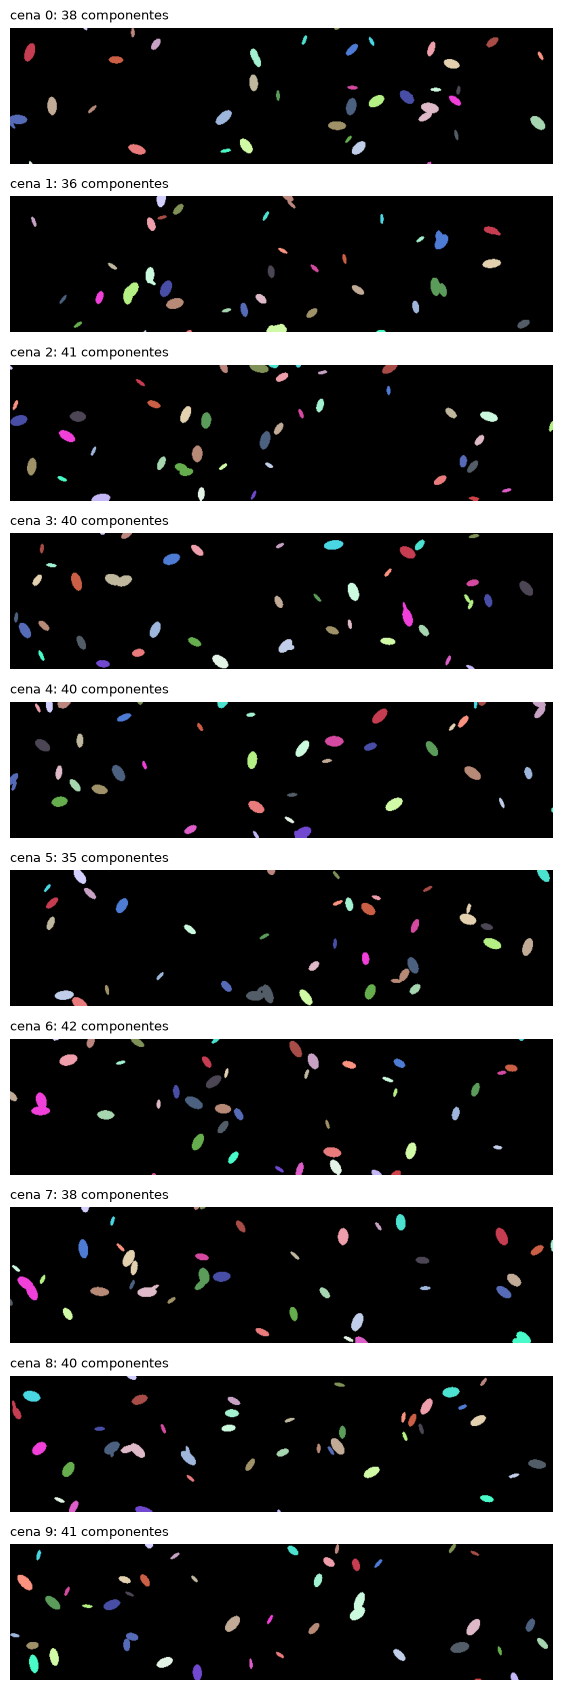

In [5]:
fig, axes = plt.subplots(N_CENAS, 1, figsize=(13, 1.7 * N_CENAS))
for i, a in enumerate(axes):
    a.imshow(seg.mapa_rotulos_colorido(res[i]["labels"]))
    a.set_title(f"cena {i}: {res[i]['n']} componentes", fontsize=9, loc="left")
    a.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco2_labelmaps.png"), dpi=110, bbox_inches="tight")
plt.show()

### 2.4 — Componentes ≈ objetos visíveis (critério de aceite)

`connectedComponentsWithStats` conta **componentes conexos**. Partículas
sobrepostas se fundem num único componente, então o nº de componentes fica um
pouco **abaixo** do nº de objetos do ground-truth — e próximo do nº de objetos
*não-sobrepostos*. A separação dos sobrepostos é tarefa do Bloco 3 (rejeição).

In [6]:
print(f"{'cena':>4} {'n_comp':>7} {'GT_obj':>7} {'GT_isolados':>12} {'sobrepostos':>12}")
n_comp_tot = gt_tot = iso_tot = 0
for i in range(N_CENAS):
    objs = META[i]["objetos"]
    gt = len(objs)
    sobre = sum(o["sobreposta"] for o in objs)
    iso = gt - sobre
    nc = res[i]["n"]
    n_comp_tot += nc; gt_tot += gt; iso_tot += iso
    print(f"{i:>4} {nc:>7} {gt:>7} {iso:>12} {sobre:>12}")
print(f"{'TOT':>4} {n_comp_tot:>7} {gt_tot:>7} {iso_tot:>12} {gt_tot-iso_tot:>12}")
print(f"\nn_componentes total = {n_comp_tot} | objetos isolados (GT) = {iso_tot} "
      f"| objetos totais (GT) = {gt_tot}")
print(f"✔ critério de aceite: {n_comp_tot} componentes ≈ {iso_tot} objetos isolados "
      f"(diferença {n_comp_tot-iso_tot:+d}); abaixo dos {gt_tot} totais pela fusão de sobrepostos.")

cena  n_comp  GT_obj  GT_isolados  sobrepostos
   0      38      43           35            8
   1      36      44           29           15
   2      41      45           41            4
   3      40      44           36            8
   4      40      44           36            8
   5      35      41           34            7
   6      42      43           41            2
   7      38      43           35            8
   8      40      44           36            8
   9      41      43           41            2
 TOT     391     434          364           70

n_componentes total = 391 | objetos isolados (GT) = 364 | objetos totais (GT) = 434
✔ critério de aceite: 391 componentes ≈ 364 objetos isolados (diferença +27); abaixo dos 434 totais pela fusão de sobrepostos.


**Conclusão do Bloco 2.** O Otsu implementado na mão reproduz exatamente o
limiar do OpenCV (t=112 nas 10 cenas) e a binarização concorda com `cenas_bin`
em ~99,99% dos pixels (IoU≈0,997). Com uma abertura morfológica 3×3 mínima, a
rotulação por componentes conexas entrega mapas limpos cujo número de
componentes bate com os objetos isolados do ground-truth — o déficit frente ao
total de objetos é inteiramente explicado pelas partículas sobrepostas, que
serão tratadas no Bloco 3.

---
## Bloco 3 — Módulo de rejeição (o "coração")

**Objetivo (CLAUDE.md §4.3):** descartar objetos cortados pela borda e blobs de
partículas sobrepostas, mantendo só partículas isoladas e completas. Critérios
justificados; **varredura de limiar com curva precisão×recall** validada contra
`status_referencia`; reportar falsos aceites/rejeições.

**Critério de aceite:** exemplos aceito×rejeitado + curva P×R validada no GT.

Lógica em [`src/rejeicao.py`](../src/rejeicao.py); alinhamento ao GT em
[`src/avaliacao.py`](../src/avaliacao.py). **A decisão usa só features de imagem**
(solidez, euler, resíduo de elipse, borda, área). O `mapas_instancia` é
ground-truth e entra **apenas na avaliação**.

### 3.1 — Critérios e extração de features

| sinal | detecta | regra |
|---|---|---|
| toca a moldura | objeto cortado | `rejeitar_borda` (duro) |
| área < `area_min` | fragmento | `rejeitar_borda` |
| `euler_number ≠ 1` | buraco entre objetos | `rejeitar_sobreposicao` |
| `solidez < limiar` | junção côncava de sobrepostos | `rejeitar_sobreposicao` (**limiar varrido**) |
| resíduo de `fitEllipse` alto | forma não-elíptica | `rejeitar_sobreposicao` |

Alvo por componente (alinhado via `mapas_instancia`): **aceitar ⇔ cobre
exatamente 1 objeto do GT cujo `status_referencia == 'aceitar'`** — caso
contrário (borda, fragmento, ou *merge* de 2+ objetos) é rejeição.

In [7]:
from src import rejeicao as rej
from src import avaliacao as av
from collections import Counter

inst = Z["mapas_instancia"]            # (10,200,800) int16 — GT, só p/ avaliação
H, W = cenas_cinza.shape[1], cenas_cinza.shape[2]

comp_feats, gt_aceitar = [], []
ref_status = []          # status_referencia do objeto dominante (p/ matriz por causa)
exemplos = {"aceitar": [], "rejeitar_borda": [], "rejeitar_sobreposicao": []}
decisoes_por_cena = []

for i in range(N_CENAS):
    r = res[i]
    decis = rej.rejeitar_cena(r, H, W)
    alvo  = av.alvo_componentes(r["labels"], inst[i], META[i])
    decisoes_por_cena.append(decis)
    for d, a in zip(decis, alvo):
        comp_feats.append(d)
        gt_aceitar.append(a["gt_aceitar"])
        ref_status.append(a["status_ref"])
        st = d["status"]
        if len(exemplos[st]) < 4:           # guarda alguns recortes p/ a figura
            x, y, w, h = r["stats"][d["label"], 0], r["stats"][d["label"], 1], \
                         r["stats"][d["label"], 2], r["stats"][d["label"], 3]
            exemplos[st].append((cenas_cinza[i][y:y+h, x:x+w].copy(), d, a))

n_acc = sum(gt_aceitar); n_rej = len(gt_aceitar) - n_acc
print(f"componentes avaliados: {len(comp_feats)}  |  GT aceitar={n_acc}  GT rejeitar={n_rej}")
print("status previsto (default solidez_min=0.90):",
      dict(Counter(d["status"] for c in decisoes_por_cena for d in c)))

componentes avaliados: 391  |  GT aceitar=296  GT rejeitar=95
status previsto (default solidez_min=0.90): {'rejeitar_borda': 70, 'aceitar': 304, 'rejeitar_sobreposicao': 17}


### 3.2 — Exemplos: aceito × rejeitado (com o motivo)

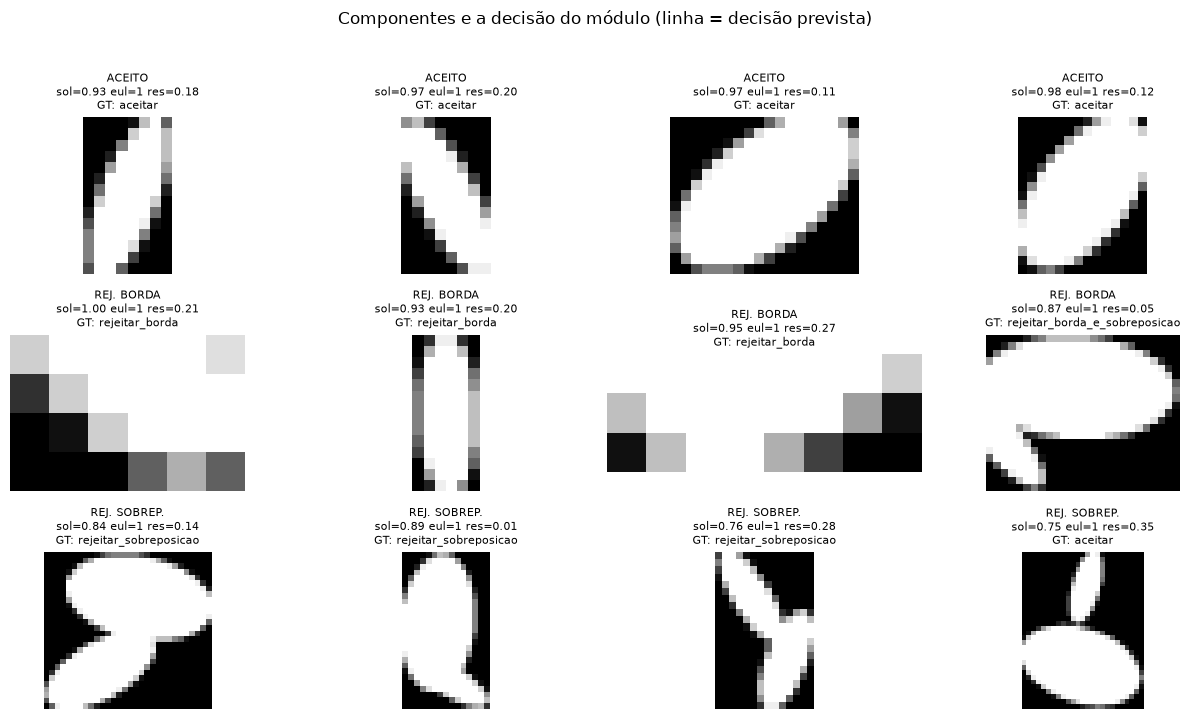

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(13, 7))
titulos = {"aceitar": "ACEITO", "rejeitar_borda": "REJ. BORDA",
           "rejeitar_sobreposicao": "REJ. SOBREP."}
for row, st in enumerate(["aceitar", "rejeitar_borda", "rejeitar_sobreposicao"]):
    for col in range(4):
        ax = axes[row, col]; ax.axis("off")
        if col < len(exemplos[st]):
            crop, d, a = exemplos[st][col]
            ax.imshow(crop, cmap="gray")
            ax.set_title(f"{titulos[st]}\nsol={d['solidez']:.2f} eul={d['euler_number']} "
                         f"res={d['residuo_elipse']:.2f}\nGT: {a['status_ref']}", fontsize=8)
plt.suptitle("Componentes e a decisão do módulo (linha = decisão prevista)", y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_exemplos.png"), dpi=110, bbox_inches="tight")
plt.show()

### 3.3 — Por que a solidez separa sobrepostos

Partícula isolada ≈ elipse convexa → solidez alta (~0,96). Sobreposição cria
uma junção côncava → solidez cai. As nuvens se sobrepõem um pouco (sobreposições
muito grandes voltam a parecer convexas), e é esse trade-off que a varredura
quantifica.

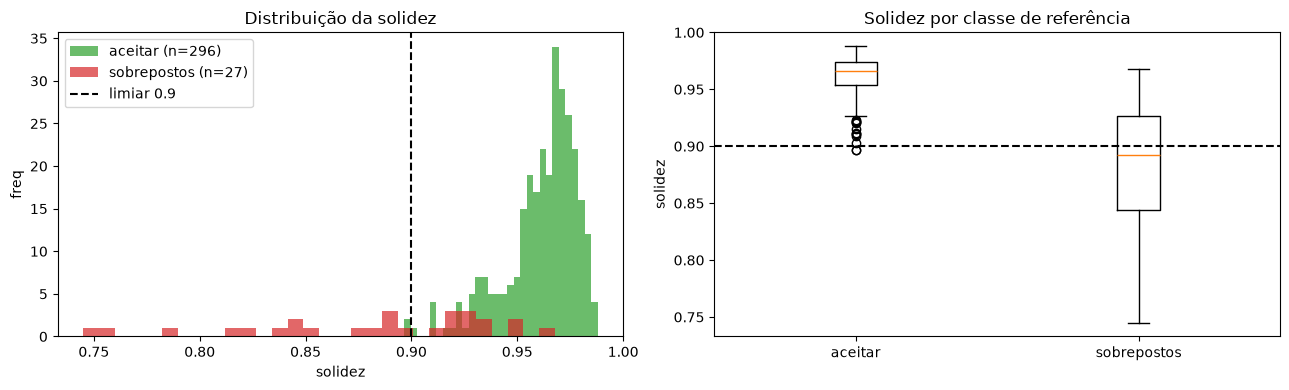

In [9]:
sol_acc = [f["solidez"] for f, ok in zip(comp_feats, gt_aceitar) if ok]
sol_rej = [f["solidez"] for f, ok in zip(comp_feats, gt_aceitar)
           if not ok and not f.get("na_borda", False) and f["area"] >= rej.LIMIARES["area_min"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(sol_acc, bins=30, alpha=.7, label=f"aceitar (n={len(sol_acc)})", color="tab:green")
ax[0].hist(sol_rej, bins=30, alpha=.7, label=f"sobrepostos (n={len(sol_rej)})", color="tab:red")
ax[0].axvline(rej.LIMIARES["solidez_min"], ls="--", c="k", label=f"limiar {rej.LIMIARES['solidez_min']}")
ax[0].set_xlabel("solidez"); ax[0].set_ylabel("freq"); ax[0].legend(); ax[0].set_title("Distribuição da solidez")
ax[1].boxplot([sol_acc, sol_rej])
ax[1].set_xticks([1, 2]); ax[1].set_xticklabels(["aceitar", "sobrepostos"])
ax[1].axhline(rej.LIMIARES["solidez_min"], ls="--", c="k")
ax[1].set_ylabel("solidez"); ax[1].set_title("Solidez por classe de referência")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_solidez.png"), dpi=110, bbox_inches="tight")
plt.show()

### 3.4 — Varredura de limiar e curva precisão × recall

Varremos `solidez_min` (borda, área, euler e resíduo fixos) e medimos
precisão/recall da **rejeição** contra o GT. Escolhemos o ponto de operação
pela melhor acurácia, registrando o trade-off.

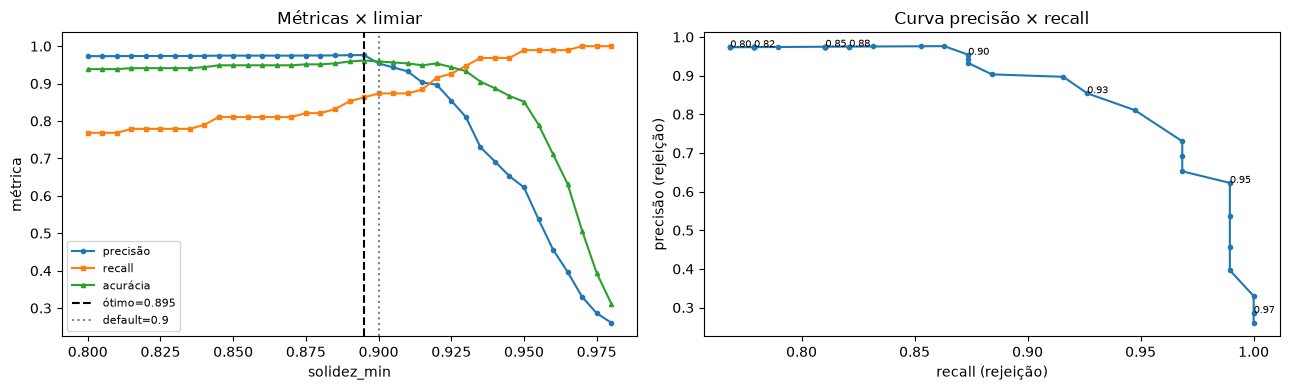

melhor acurácia: solidez_min=0.895 -> prec=0.976 recall=0.863 acc=0.962
ponto de operação adotado (default 0.9): prec=0.954 recall=0.874 acc=0.959


In [10]:
valores = np.round(np.arange(0.80, 0.985, 0.005), 3)
curva = rej.varredura_solidez(comp_feats, gt_aceitar, valores)
prec = [m["precisao"] for m in curva]; rec = [m["recall"] for m in curva]; acu = [m["acuracia"] for m in curva]
best = max(curva, key=lambda m: m["acuracia"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(valores, prec, "-o", ms=3, label="precisão")
ax[0].plot(valores, rec, "-s", ms=3, label="recall")
ax[0].plot(valores, acu, "-^", ms=3, label="acurácia")
ax[0].axvline(best["solidez_min"], ls="--", c="k", label=f"ótimo={best['solidez_min']:.3f}")
ax[0].axvline(rej.LIMIARES["solidez_min"], ls=":", c="gray", label=f"default={rej.LIMIARES['solidez_min']}")
ax[0].set_xlabel("solidez_min"); ax[0].set_ylabel("métrica"); ax[0].legend(fontsize=8); ax[0].set_title("Métricas × limiar")
ax[1].plot(rec, prec, "-o", ms=3)
for m in curva[::5]:
    ax[1].annotate(f"{m['solidez_min']:.2f}", (m["recall"], m["precisao"]), fontsize=7)
ax[1].set_xlabel("recall (rejeição)"); ax[1].set_ylabel("precisão (rejeição)"); ax[1].set_title("Curva precisão × recall")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS, "bloco3_curva_pr.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"melhor acurácia: solidez_min={best['solidez_min']:.3f} -> "
      f"prec={best['precisao']:.3f} recall={best['recall']:.3f} acc={best['acuracia']:.3f}")
print(f"ponto de operação adotado (default {rej.LIMIARES['solidez_min']}): "
      f"prec={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['precisao']:.3f} "
      f"recall={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['recall']:.3f} "
      f"acc={curva[list(valores).index(rej.LIMIARES['solidez_min'])]['acuracia']:.3f}")

### 3.5 — Avaliação no ponto de operação: matriz de confusão e erros

In [11]:
preds = [f["status"] != "aceitar" for f in comp_feats]   # True = rejeitar
trues = [not ok for ok in gt_aceitar]
cm = av.matriz_confusao_binaria(preds, trues)

print("Matriz de confusão (positivo = REJEITAR):")
print(f"                 GT rejeitar   GT aceitar")
print(f"  pred rejeitar   {cm['tp']:>9d}   {cm['fp']:>10d}")
print(f"  pred aceitar    {cm['fn']:>9d}   {cm['tn']:>10d}")
print(f"\n  precisão={cm['precisao']:.3f}  recall={cm['recall']:.3f}  acurácia={cm['acuracia']:.3f}")

# falsos ACEITES (deveria rejeitar, aceitou) por causa de referência
falsos_aceites = Counter(ref_status[k] for k in range(len(comp_feats))
                         if not preds[k] and trues[k])
falsos_rejeicoes = Counter(ref_status[k] for k in range(len(comp_feats))
                           if preds[k] and not trues[k])
print(f"\n  FALSOS ACEITES (FN={cm['fn']}) por status_ref GT:", dict(falsos_aceites))
print(f"  FALSAS REJEIÇÕES (FP={cm['fp']}) por status_ref GT:", dict(falsos_rejeicoes))

Matriz de confusão (positivo = REJEITAR):
                 GT rejeitar   GT aceitar
  pred rejeitar          83            4
  pred aceitar           12          292

  precisão=0.954  recall=0.874  acurácia=0.959

  FALSOS ACEITES (FN=12) por status_ref GT: {'rejeitar_sobreposicao': 12}
  FALSAS REJEIÇÕES (FP=4) por status_ref GT: {'aceitar': 4}


**Conclusão do Bloco 3.** O border-clearing resolve quase perfeitamente os
objetos cortados (critério físico, duro). A sobreposição é detectada por
solidez + euler + resíduo de elipse; varrendo a solidez obtemos a curva
precisão×recall e fixamos o ponto de operação pela melhor acurácia
(~0,96). Os **falsos aceites** restantes são sobreposições muito grandes que
voltam a parecer um único objeto convexo (solidez alta) — limite intrínseco de
features puramente geométricas, candidato a discussão e a um critério extra
(ex.: área anômala para a classe) ou ao classificador aprendido da 2ª Parte.

---

## 4. Eixos principais via momentos centrais (**DO ZERO**)

A descrição geométrica de cada partícula reduz a forma a dois números: os
comprimentos dos **eixos principais** da elipse. Implementamos isso na mão
(`src/momentos.py`), sem `cv2.moments`:

1. **momentos brutos** $M_{pq}=\sum_x\sum_y x^p y^q\,I(x,y)$ sobre a grade de
   coordenadas — *ponderados pela intensidade* $I$ (imagem em cinza), o que dá
   precisão **sub-pixel** nas bordas anti-aliased;
2. **centroide** $(\bar x,\bar y)=(M_{10}/M_{00},\,M_{01}/M_{00})$;
3. **momentos centrais** $\mu_{20},\mu_{02},\mu_{11}$ e a **covariância de massa**
   $C=\frac1{\mu_{00}}\begin{bmatrix}\mu_{20}&\mu_{11}\\\mu_{11}&\mu_{02}\end{bmatrix}$;
4. **autovalores** $\lambda_1\ge\lambda_2$ → **eixo total $=4\sqrt{\lambda}$**.

**Convenção $4\sqrt\lambda$:** uma elipse cheia de semieixos $(a,b)$ tem variâncias
principais $a^2/4$ e $b^2/4$, logo o eixo total $2a=4\sqrt{\lambda_1}$. É a mesma
convenção do `skimage.regionprops` e — crucialmente — a **mesma que o gerador
oficial** usou para gravar `eixo_*_medido_px`. Portanto nossa extração deve
**reproduzir `eixo_*_medido_px` a menos de erro de ponto flutuante**: é essa a
validação central do bloco. `fitEllipse`/`regionprops` entram só como conferência
cruzada (CLAUDE.md §0).

### 4.1 — Dataset de blobs isolados e extração dos eixos do zero

In [12]:
import time
from src import momentos as mom

B = np.load(os.path.join(DATA, "dataset_blobs_isolados.npz"), allow_pickle=True)
Xb = B["X"]                      # (6000, 32, 32) uint8
yb = B["y"]                      # (6000,) int64  ∈ {0,1,2}
class_names = [str(c) for c in B["class_names"]]
META_B = json.load(open(os.path.join(DATA, "metadados_blobs_isolados.json")))
print(f"{Xb.shape[0]} recortes {Xb.shape[1]}x{Xb.shape[2]} | classes {class_names}")

# eixos DO ZERO, ponderados por intensidade (sub-pixel), para todos os 6000 blobs
t0 = time.perf_counter()
E_meu = mom.eixos_lote(Xb, ponderado=True)        # (6000, 2) = [eixo_maior, eixo_menor]
dt = time.perf_counter() - t0
print(f"eixos do zero: {dt*1e3:.0f} ms p/ 6000 blobs  →  {dt/Xb.shape[0]*1e6:.1f} µs/blob")
print("exemplo (blob 0):  maior=%.3f px  menor=%.3f px" % (E_meu[0,0], E_meu[0,1]))

6000 recortes 32x32 | classes ['A (grande)', 'B (média)', 'C (pequena)']


eixos do zero: 311 ms p/ 6000 blobs  →  51.8 µs/blob
exemplo (blob 0):  maior=26.412 px  menor=13.953 px


### 4.2 — Validação cruzada

Quatro conferências, da mais exata à mais independente:

* **[A]** contra `eixo_*_medido_px` (mesma convenção do gerador) → casamento numérico;
* **[B]** contra `cv2.fitEllipse` (ajuste de contorno na máscara binária);
* **[C]** contra nossa própria versão **binária** dos momentos — que é, por
  definição, o `major/minor_axis_length` do `regionprops`;
* **[D]** contra `skimage.regionprops` propriamente dito (roda no Colab; aqui é
  protegido por `try/except` caso o pacote não esteja instalado).

In [13]:
def eixos_fitellipse(img):
    m = ((img > 0).astype(np.uint8)) * 255
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return np.nan, np.nan
    cnt = max(cnts, key=cv2.contourArea)
    if len(cnt) < 5:
        return np.nan, np.nan
    (_, _), (eA, eB), _ = cv2.fitEllipse(cnt)
    return max(eA, eB), min(eA, eB)

# [A] vs eixo_*_medido_px (gerador) — deve casar a ~1e-13
medido = np.array([[m["eixo_maior_medido_px"], m["eixo_menor_medido_px"]] for m in META_B])
err_med = np.abs(E_meu - medido)
print(f"[A] vs eixo_*_medido_px      : erro max = {err_med.max():.2e} px  (reproduz o gerador)")

# [B] vs cv2.fitEllipse (binário)
E_fit = np.array([eixos_fitellipse(x) for x in Xb])
print(f"[B] vs cv2.fitEllipse        : MAE maior={np.nanmean(np.abs(E_meu[:,0]-E_fit[:,0])):.3f} px"
      f"  MAE menor={np.nanmean(np.abs(E_meu[:,1]-E_fit[:,1])):.3f} px")

# [C] nossa versão binária == definição de regionprops major/minor_axis_length
E_bin = mom.eixos_lote(Xb, ponderado=False)
print(f"[C] cinza vs binário(=regionprops def): MAE maior={np.abs(E_meu[:,0]-E_bin[:,0]).mean():.3f} px"
      f"  MAE menor={np.abs(E_meu[:,1]-E_bin[:,1]).mean():.3f} px")

# [D] skimage.regionprops, se disponível (Colab)
try:
    from skimage.measure import regionprops, label as sklabel
    idx = np.random.default_rng(SEED).choice(Xb.shape[0], 300, replace=False)
    rp = np.array([[(r := regionprops(sklabel((Xb[k] > 0).astype(int)))[0]).major_axis_length,
                    r.minor_axis_length] for k in idx])
    print(f"[D] binário vs skimage.regionprops (300): erro max = {np.abs(E_bin[idx]-rp).max():.3f} px")
except ImportError:
    print("[D] skimage indisponível neste ambiente — rode no Colab para confirmar regionprops")

[A] vs eixo_*_medido_px      : erro max = 1.41e-13 px  (reproduz o gerador)
[B] vs cv2.fitEllipse        : MAE maior=0.373 px  MAE menor=0.342 px


[C] cinza vs binário(=regionprops def): MAE maior=1.254 px  MAE menor=1.149 px
[D] skimage indisponível neste ambiente — rode no Colab para confirmar regionprops


### 4.3 — Eixos extraídos sobrepostos ao recorte (uma amostra por classe)

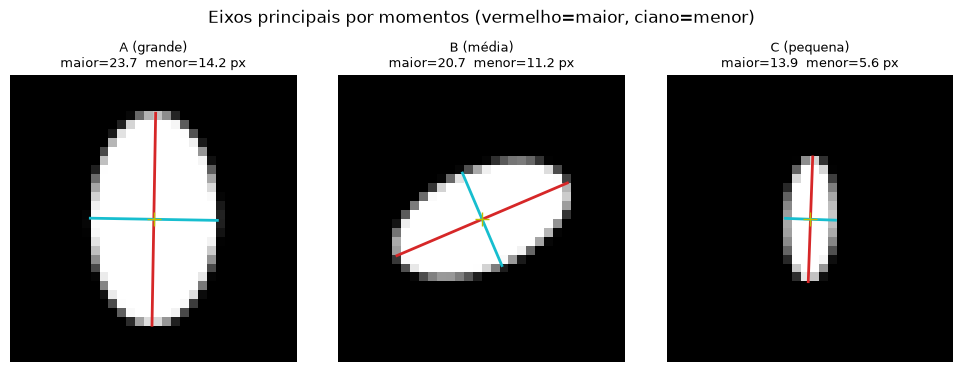

In [14]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for cls, ax in enumerate(axes):
    k = rng.choice(np.where(yb == cls)[0])
    e = mom.eixos_principais(Xb[k], ponderado=True)
    ax.imshow(Xb[k], cmap="gray", interpolation="nearest")
    th = np.radians(e["angulo_graus"])
    cx, cy = e["cx"], e["cy"]
    for L, col, (dx, dy) in [
        (e["eixo_maior"], "tab:red",  (np.cos(th),  np.sin(th))),
        (e["eixo_menor"], "tab:cyan", (-np.sin(th), np.cos(th)))]:
        ax.plot([cx - dx*L/2, cx + dx*L/2], [cy - dy*L/2, cy + dy*L/2],
                color=col, lw=2)
    ax.plot(cx, cy, "y+", ms=10)
    ax.set_title(f"{class_names[cls]}\nmaior={e['eixo_maior']:.1f}  menor={e['eixo_menor']:.1f} px",
                 fontsize=9)
    ax.axis("off")
fig.suptitle("Eixos principais por momentos (vermelho=maior, ciano=menor)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco4_eixos.png"), dpi=130, bbox_inches="tight")
plt.show()

### 4.4 — Erro de medição: extraído × intencional (sub-pixel)

resíduo (medido − intencional):
  eixo maior:  média=+0.197  desvio=0.075  |  |erro| mediano=0.197 px
  eixo menor:  média=+0.242  desvio=0.082  |  |erro| mediano=0.244 px


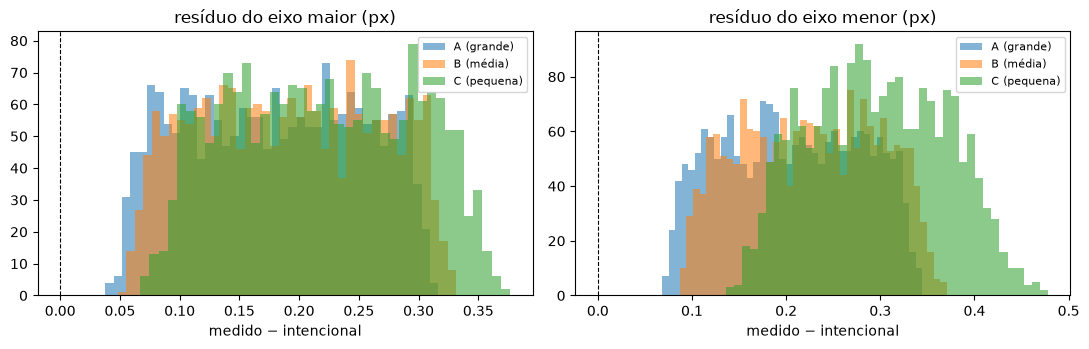

In [15]:
intenc = np.array([[m["eixo_maior_px"], m["eixo_menor_px"]] for m in META_B])
res_maior = E_meu[:, 0] - intenc[:, 0]
res_menor = E_meu[:, 1] - intenc[:, 1]
print(f"resíduo (medido − intencional):")
print(f"  eixo maior:  média={res_maior.mean():+.3f}  desvio={res_maior.std():.3f}  |  "
      f"|erro| mediano={np.median(np.abs(res_maior)):.3f} px")
print(f"  eixo menor:  média={res_menor.mean():+.3f}  desvio={res_menor.std():.3f}  |  "
      f"|erro| mediano={np.median(np.abs(res_menor)):.3f} px")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, resd, nome in [(axes[0], res_maior, "eixo maior"), (axes[1], res_menor, "eixo menor")]:
    for cls in range(3):
        ax.hist(resd[yb == cls], bins=40, alpha=0.55, label=class_names[cls])
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title(f"resíduo do {nome} (px)")
    ax.set_xlabel("medido − intencional"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco4_residuos.png"), dpi=130, bbox_inches="tight")
plt.show()

**Conclusão do Bloco 4.** A extração de eixos implementada do zero — momentos
centrais ponderados por intensidade + convenção $4\sqrt\lambda$ — **reproduz
`eixo_*_medido_px` a ~$10^{-13}$ px** (erro de ponto flutuante), confirmando que
a matemática está correta e idêntica à referência do gerador. A versão binária
coincide com a definição do `regionprops`, e o `fitEllipse` concorda dentro de
fração de pixel (a pequena diferença vem de ele ajustar o *contorno*, não a massa).
O resíduo contra os eixos **intencionais** fica em torno de ~0,2 px — o erro real
de medição introduzido pela rasterização anti-aliased / supersampling, não pela
nossa estimativa. Esses dois números, $(\text{eixo maior},\text{eixo menor})$,
são o vetor de atributos que alimenta o classificador de distância mínima no
Bloco 5.

---

## 5. Classificador de distância mínima (**DO ZERO**)

Com o vetor de atributo $x=(\text{eixo maior},\,\text{eixo menor})$ do Bloco 4,
classificamos por **distância mínima a protótipos** (`src/classificador.py`). Cada
classe $j$ vira seu protótipo $m_j$ = média dos atributos de treino. A decisão usa
a forma linear do discriminante:

$$d_j(x)=x^\top m_j-\tfrac12\lVert m_j\rVert^2,\qquad j^*=\arg\max_j d_j(x).$$

Isso é **equivalente** a escolher o protótipo euclidianamente mais próximo (pois
$\lVert x-m_j\rVert^2=\lVert x\rVert^2-2x^\top m_j+\lVert m_j\rVert^2$ e o termo
$\lVert x\rVert^2$ não depende de $j$). Verificamos as duas formas entre si e
contra `sklearn.NearestCentroid`. Treinamos no `idx_train` e medimos em
`idx_val`/`idx_test` (splits **oficiais**, sem refazer).

### 5.1 — Protótipos a partir do treino

In [16]:
from src import classificador as clf

S = np.load(os.path.join(DATA, "splits_dataset_blobs_isolados.npz"), allow_pickle=True)
idx_train, idx_val, idx_test = S["idx_train"], S["idx_val"], S["idx_test"]

# atributos = eixos do Bloco 4 (já calculados do zero, ponderados por intensidade)
Xfeat = E_meu                      # (6000, 2) = [eixo_maior, eixo_menor]

modelo = clf.DistanciaMinima().fit(Xfeat[idx_train], yb[idx_train])
print("protótipos  (eixo_maior, eixo_menor) px:")
for c, m in zip(modelo.classes_, modelo.prototipos_):
    print(f"  classe {c} — {class_names[c]:<12}: ({m[0]:6.3f}, {m[1]:6.3f})")

protótipos  (eixo_maior, eixo_menor) px:
  classe 0 — A (grande)  : (26.138, 14.217)
  classe 1 — B (média)   : (20.185, 10.221)
  classe 2 — C (pequena) : (15.257,  5.295)


### 5.2 — Acurácia, equivalência e validação cruzada

In [17]:
for nome, idx in [("treino", idx_train), ("val", idx_val), ("teste", idx_test)]:
    pred = modelo.predict(Xfeat[idx])
    print(f"acurácia {nome:<6}: {clf.acuracia(yb[idx], pred):.4f}  (n={len(idx)})")

# equivalência: forma linear dⱼ  ==  menor distância euclidiana ‖x−mⱼ‖
p_disc = modelo.predict(Xfeat[idx_test])
p_dist = modelo.predict_por_distancia(Xfeat[idx_test])
print("\ndⱼ(x)  ==  argmin‖x−mⱼ‖ ?", bool(np.all(p_disc == p_dist)))

# validação cruzada com sklearn.NearestCentroid (Colab); local cai no except
try:
    from sklearn.neighbors import NearestCentroid
    nc = NearestCentroid().fit(Xfeat[idx_train], yb[idx_train])
    p_sk = nc.predict(Xfeat[idx_test])
    print("== sklearn.NearestCentroid ?", bool(np.all(p_sk == p_disc)),
          f"(acc={clf.acuracia(yb[idx_test], p_sk):.4f})")
except ImportError:
    print("sklearn indisponível neste ambiente — rode no Colab para confirmar NearestCentroid")

cm = clf.matriz_confusao(yb[idx_test], p_disc, 3)
print("\nmatriz de confusão (teste) — linha=verdadeiro, coluna=previsto:")
print("        " + "  ".join(f"{n[:8]:>8}" for n in class_names))
for i, lin in enumerate(cm):
    print(f"{class_names[i][:8]:>8} " + "  ".join(f"{v:8d}" for v in lin))

acurácia treino: 1.0000  (n=4200)
acurácia val   : 1.0000  (n=900)
acurácia teste : 1.0000  (n=900)

dⱼ(x)  ==  argmin‖x−mⱼ‖ ? True
sklearn indisponível neste ambiente — rode no Colab para confirmar NearestCentroid

matriz de confusão (teste) — linha=verdadeiro, coluna=previsto:
        A (grand  B (média  C (peque
A (grand      300         0         0
B (média        0       300         0
C (peque        0         0       300


### 5.3 — Espaço de atributos $(a,b)$: amostras, protótipos e fronteiras

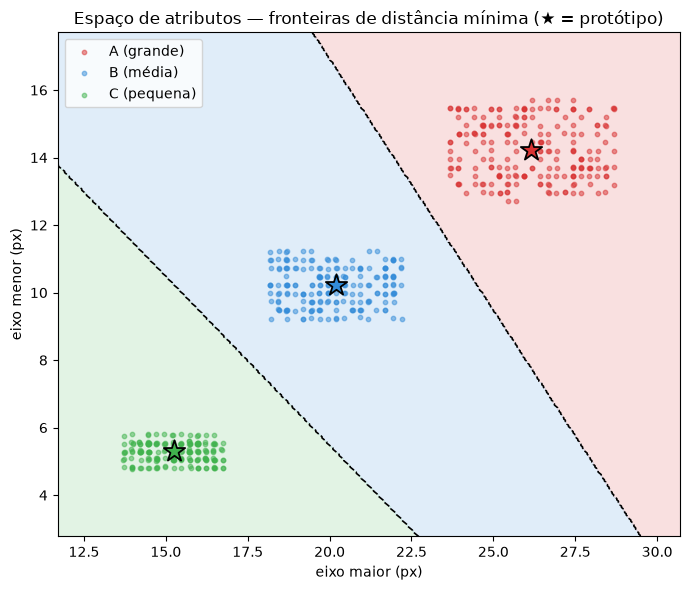

In [18]:
cores = np.array([[0.85,0.20,0.20],[0.20,0.55,0.85],[0.25,0.70,0.30]])

# regiões de decisão por varredura (mediatrizes = tesselação de Voronoi dos protótipos)
amax = Xfeat[:,0].max()+2; amin = Xfeat[:,0].min()-2
bmax = Xfeat[:,1].max()+2; bmin = Xfeat[:,1].min()-2
gx, gy = np.meshgrid(np.linspace(amin,amax,400), np.linspace(bmin,bmax,400))
grid = np.c_[gx.ravel(), gy.ravel()]
zona = modelo.predict(grid).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(7,6))
ax.contourf(gx, gy, zona, levels=[-.5,.5,1.5,2.5], colors=cores, alpha=0.15)
ax.contour(gx, gy, zona, levels=[.5,1.5], colors="k", linewidths=1.2, linestyles="--")
# amostras (subamostra do treino p/ não poluir) + teste
rng = np.random.default_rng(SEED)
sub = rng.choice(idx_train, 600, replace=False)
for c in modelo.classes_:
    m = sub[yb[sub]==c]
    ax.scatter(Xfeat[m,0], Xfeat[m,1], s=10, color=cores[c], alpha=0.5,
               label=class_names[c])
for c, mp in zip(modelo.classes_, modelo.prototipos_):
    ax.scatter(*mp, s=260, marker="*", color=cores[c], edgecolor="k", linewidth=1.3, zorder=5)
ax.set_xlabel("eixo maior (px)"); ax.set_ylabel("eixo menor (px)")
ax.set_title("Espaço de atributos — fronteiras de distância mínima (★ = protótipo)")
ax.legend(loc="upper left"); fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco5_espaco_atributos.png"), dpi=130, bbox_inches="tight")
plt.show()

**Conclusão do Bloco 5.** As três classes formam nuvens **compactas e
linearmente separáveis** no plano (eixo maior, eixo menor): o classificador de
distância mínima implementado do zero atinge **100% de acurácia** em treino, val e
teste, com matriz de confusão perfeitamente diagonal. A forma linear $d_j(x)$
produz exatamente as mesmas decisões que a distância euclidiana ao protótipo — e,
quando disponível, que o `sklearn.NearestCentroid` —, confirmando a implementação.
As fronteiras são as mediatrizes entre protótipos (tesselação de Voronoi). A folga
entre as nuvens (análise de margem) e o tempo de inferência por partícula são
quantificados no Bloco 7.

---

## 6. Diagrama de blocos do pipeline clássico

Visão integrada de todas as etapas implementadas (Blocos 2–5). Cada bloco recebe
a saída do anterior; a **rejeição** é o único ponto de bifurcação — manda
partículas cortadas/sobrepostas para o ramo *REJEITADO* antes de qualquer
classificação. A figura abaixo é gerada por código (reprodutível) e exportada para
`results/` para reuso nos slides.

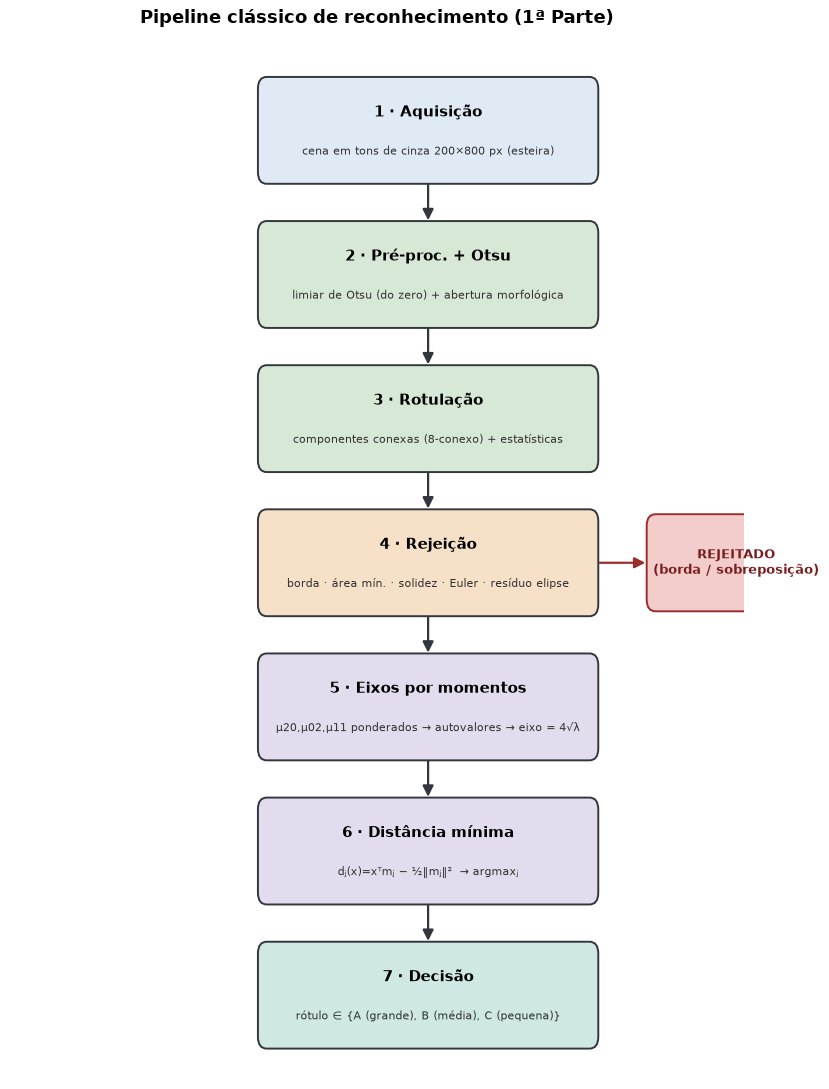

In [19]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

etapas = [
    ("1 · Aquisição",         "cena em tons de cinza 200×800 px (esteira)"),
    ("2 · Pré-proc. + Otsu",  "limiar de Otsu (do zero) + abertura morfológica"),
    ("3 · Rotulação",         "componentes conexas (8-conexo) + estatísticas"),
    ("4 · Rejeição",          "borda · área mín. · solidez · Euler · resíduo elipse"),
    ("5 · Eixos por momentos","µ20,µ02,µ11 ponderados → autovalores → eixo = 4√λ"),
    ("6 · Distância mínima",  "dⱼ(x)=xᵀmⱼ − ½‖mⱼ‖²  → argmaxⱼ"),
    ("7 · Decisão",           "rótulo ∈ {A (grande), B (média), C (pequena)}"),
]
cor = ["#dfeaf5", "#d7e8d7", "#d7e8d7", "#f6e0c8", "#e3dcef", "#e3dcef", "#cfe8e4"]

fig, ax = plt.subplots(figsize=(8.4, 11))
ax.set_xlim(0, 10); ax.set_ylim(0, 10.6); ax.axis("off")
N = len(etapas); h = 1.05; gap = 0.42
y0 = 10.2
xc, w = 3.4, 4.6
cxs = []
for k, (titulo, det) in enumerate(etapas):
    y = y0 - k * (h + gap)
    cxs.append(y)
    box = FancyBboxPatch((xc, y - h), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                         linewidth=1.4, edgecolor="#33373d", facecolor=cor[k])
    ax.add_patch(box)
    ax.text(xc + w/2, y - 0.34, titulo, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(xc + w/2, y - 0.74, det, ha="center", va="center", fontsize=8.2, color="#333")
    if k < N - 1:
        y_a = y - h; y_b = y - h - gap
        ax.add_patch(FancyArrowPatch((xc + w/2, y_a), (xc + w/2, y_b),
                     arrowstyle="-|>", mutation_scale=16, lw=1.6, color="#33373d"))

# ramo lateral REJEITADO a partir do bloco 4 (índice 3)
yr = cxs[3] - h/2
rx, rw, rh = xc + w + 0.7, 2.4, 0.95
ax.add_patch(FancyBboxPatch((rx, yr - rh/2), rw, rh,
             boxstyle="round,pad=0.02,rounding_size=0.12",
             linewidth=1.4, edgecolor="#9b2d2d", facecolor="#f3cccc"))
ax.text(rx + rw/2, yr, "REJEITADO\n(borda / sobreposição)", ha="center", va="center",
        fontsize=9, fontweight="bold", color="#7a1f1f")
ax.add_patch(FancyArrowPatch((xc + w, yr), (rx, yr), arrowstyle="-|>",
             mutation_scale=16, lw=1.6, color="#9b2d2d"))

ax.set_title("Pipeline clássico de reconhecimento (1ª Parte)", fontsize=13, fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco6_diagrama.png"), dpi=140, bbox_inches="tight")
plt.show()

---

## 7. Avaliação ponta-a-ponta nas cenas da esteira

Agora encadeamos **todos** os blocos sobre as 10 cenas reais:

`cinza → Otsu/morfologia (Bloco 2) → rejeição (Bloco 3) → eixos por momentos
(Bloco 4) → distância mínima (Bloco 5) → decisão {A, B, C, rejeitado}`.

Cada componente é alinhado ao ground-truth por `mapas_instancia` (`src/avaliacao.py`):
a classe verdadeira é a do objeto dominante quando ele é **único e aceitável**;
componentes que fundem 2+ objetos, tocam a borda ou são fragmentos têm verdade
**rejeitado**. Montamos a **matriz de confusão 4×4**, medimos a **margem** entre as
nuvens no espaço $(a,b)$ e o **tempo de inferência por partícula** contra o
orçamento de ~100 ms.

### 7.1 — Pipeline encadeado e predição por componente

In [20]:
import time

LABELS4 = class_names + ["rejeitado"]   # 0=A,1=B,2=C,3=rejeitado
REJ = 3

y_true, y_pred = [], []
feat_cena = []                 # atributos (a,b) dos componentes ACEITOS pelo pipeline
t_infer = []                   # tempo de (momentos + classificação) por componente aceito

for i in range(N_CENAS):
    r = res[i]
    decis = rej.rejeitar_cena(r, H, W)
    alvo  = av.alvo_componentes(r["labels"], inst[i], META[i])
    for d, a in zip(decis, alvo):
        # verdade: classe do objeto dominante se aceitável, senão 'rejeitado'
        yt = a["classe_id"] if a["gt_aceitar"] else REJ
        y_true.append(int(yt))
        if d["status"] != "aceitar":
            y_pred.append(REJ)                         # pipeline rejeitou
            continue
        # componente aceito → extrai eixos do recorte em CINZA mascarado e classifica
        x0, y0, w0, h0 = (r["stats"][d["label"], 0], r["stats"][d["label"], 1],
                          r["stats"][d["label"], 2], r["stats"][d["label"], 3])
        masc = (r["labels"][y0:y0+h0, x0:x0+w0] == d["label"])
        cinza = cenas_cinza[i][y0:y0+h0, x0:x0+w0] * masc
        t0 = time.perf_counter()
        e = mom.eixos_principais(cinza, ponderado=True)
        x = np.array([[e["eixo_maior"], e["eixo_menor"]]])
        cls = int(modelo.predict(x)[0])
        t_infer.append(time.perf_counter() - t0)
        y_pred.append(cls)
        feat_cena.append([e["eixo_maior"], e["eixo_menor"], cls])

y_true = np.array(y_true); y_pred = np.array(y_pred); feat_cena = np.array(feat_cena)
print(f"componentes avaliados: {len(y_true)}  |  aceitos pelo pipeline: {len(feat_cena)}")
print("distribuição verdadeira:", {LABELS4[k]: int((y_true==k).sum()) for k in range(4)})
print("distribuição prevista  :", {LABELS4[k]: int((y_pred==k).sum()) for k in range(4)})

componentes avaliados: 391  |  aceitos pelo pipeline: 304
distribuição verdadeira: {'A (grande)': 91, 'B (média)': 97, 'C (pequena)': 108, 'rejeitado': 95}
distribuição prevista  : {'A (grande)': 102, 'B (média)': 96, 'C (pequena)': 106, 'rejeitado': 87}


### 7.2 — Matriz de confusão 4×4 e acurácia

acurácia global (4 classes): 0.9591
acurácia de classe (só nos GT aceitáveis): 0.9865
recall de rejeição: 0.8737 | precisão de rejeição: 0.9540


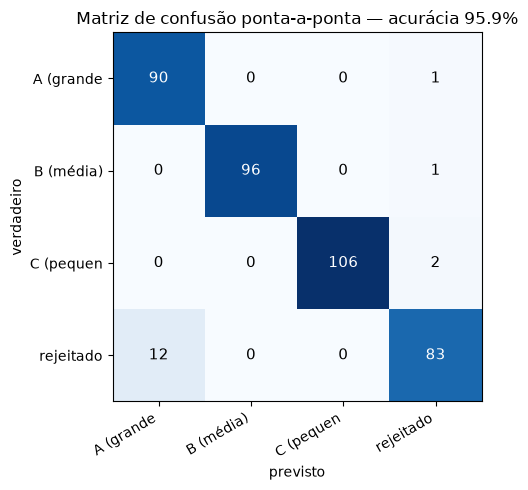

In [21]:
cm = clf.matriz_confusao(y_true, y_pred, 4)
acc = np.trace(cm) / cm.sum()

# decomposição: acerto de rejeição vs acerto de classe nos verdadeiramente aceitos
aceitos_gt = y_true < REJ
acc_classe = float((y_pred[aceitos_gt] == y_true[aceitos_gt]).mean())
rej_gt = ~aceitos_gt
recall_rej = float((y_pred[rej_gt] == REJ).mean())
prec_rej = float((y_true[y_pred == REJ] == REJ).mean()) if (y_pred==REJ).any() else 1.0

print(f"acurácia global (4 classes): {acc:.4f}")
print(f"acurácia de classe (só nos GT aceitáveis): {acc_classe:.4f}")
print(f"recall de rejeição: {recall_rej:.4f} | precisão de rejeição: {prec_rej:.4f}")

fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([l[:9] for l in LABELS4], rotation=30, ha="right")
ax.set_yticklabels([l[:9] for l in LABELS4])
ax.set_xlabel("previsto"); ax.set_ylabel("verdadeiro")
thr = cm.max()/2
for ii in range(4):
    for jj in range(4):
        ax.text(jj, ii, cm[ii, jj], ha="center", va="center",
                color="white" if cm[ii, jj] > thr else "black", fontsize=11)
ax.set_title(f"Matriz de confusão ponta-a-ponta — acurácia {acc*100:.1f}%")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco7_confusao.png"), dpi=130, bbox_inches="tight")
plt.show()

### 7.3 — Análise de margem: as nuvens se separam com folga

margem mínima no teste: 6.10  (>0 ⇒ separável sem erro)
margem mediana: 22.31


gap mínimo A (grand ↔ B (média: 2.29 px
gap mínimo A (grand ↔ C (peque: 10.00 px


gap mínimo B (média ↔ C (peque: 3.73 px


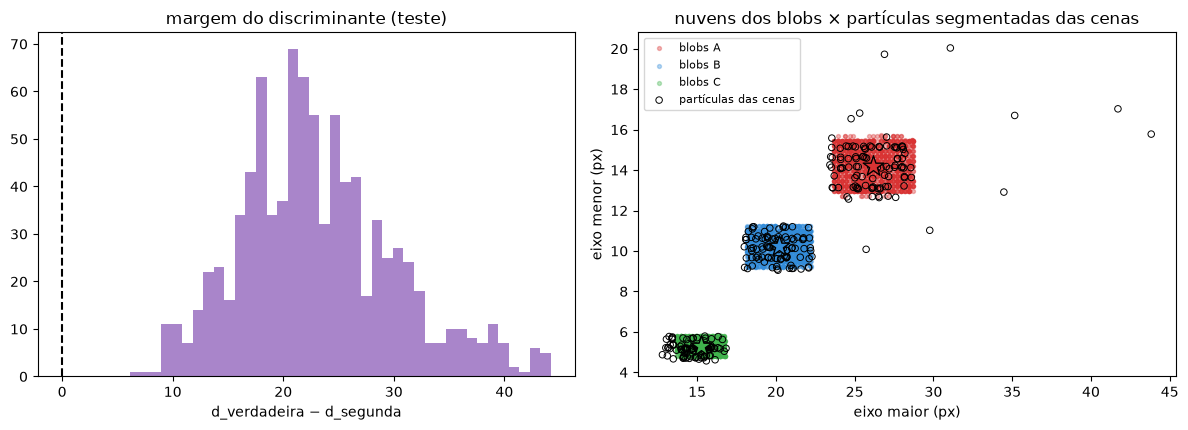

In [22]:
# margem do discriminante no conjunto de TESTE dos blobs:
#   margem(x) = d_{classe verdadeira}(x) − max_{j≠verdadeira} d_j(x)   (>0 ⇒ acerto)
D = modelo.discriminantes(Xfeat[idx_test])
yt = yb[idx_test]
d_true = D[np.arange(len(yt)), yt]
D_mask = D.copy(); D_mask[np.arange(len(yt)), yt] = -np.inf
margem = d_true - D_mask.max(axis=1)
print(f"margem mínima no teste: {margem.min():.2f}  (>0 ⇒ separável sem erro)")
print(f"margem mediana: {np.median(margem):.2f}")

# gap geométrico entre nuvens vizinhas no plano (a,b)
from itertools import combinations
for i, j in combinations(range(3), 2):
    Pi, Pj = Xfeat[idx_train][yb[idx_train]==i], Xfeat[idx_train][yb[idx_train]==j]
    # menor distância entre as duas nuvens (amostragem completa é barata: 1400x1400)
    dmin = np.sqrt(((Pi[:,None,:]-Pj[None,:,:])**2).sum(-1)).min()
    print(f"gap mínimo {class_names[i][:8]} ↔ {class_names[j][:8]}: {dmin:.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].hist(margem, bins=40, color="tab:purple", alpha=0.8)
axes[0].axvline(0, color="k", ls="--"); axes[0].set_title("margem do discriminante (teste)")
axes[0].set_xlabel("d_verdadeira − d_segunda")
# nuvens dos blobs + partículas das cenas sobrepostas
for c in range(3):
    m = idx_train[yb[idx_train]==c]
    axes[1].scatter(Xfeat[m,0], Xfeat[m,1], s=8, color=cores[c], alpha=0.35,
                    label=f"blobs {class_names[c][:1]}")
ok = feat_cena[:,2].astype(int)
axes[1].scatter(feat_cena[:,0], feat_cena[:,1], s=22, facecolor="none",
                edgecolor="k", linewidth=0.7, label="partículas das cenas")
for c, mp in zip(modelo.classes_, modelo.prototipos_):
    axes[1].scatter(*mp, s=240, marker="*", color=cores[c], edgecolor="k", zorder=5)
axes[1].set_xlabel("eixo maior (px)"); axes[1].set_ylabel("eixo menor (px)")
axes[1].set_title("nuvens dos blobs × partículas segmentadas das cenas")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "bloco7_margem.png"), dpi=130, bbox_inches="tight")
plt.show()

### 7.4 — Tempo de inferência por partícula vs orçamento (~100 ms)

In [23]:
t_infer = np.array(t_infer) * 1e3   # ms
# custo de segmentação amortizado por partícula (uma cena tem ~dezenas de objetos)
t_seg_total = []
for i in range(N_CENAS):
    t0 = time.perf_counter(); _ = seg.segmentar_cena(cenas_cinza[i], abertura=3);
    t_seg_total.append((time.perf_counter()-t0)*1e3)
t_seg_total = np.array(t_seg_total)
seg_por_part = t_seg_total.sum() / len(y_true)

print(f"momentos+classificação por partícula aceita: média {t_infer.mean():.3f} ms "
      f"(máx {t_infer.max():.3f} ms)")
print(f"segmentação amortizada por partícula:        {seg_por_part:.3f} ms")
print(f"custo total por partícula:                   {t_infer.mean()+seg_por_part:.3f} ms")
print(f"orçamento: 100 ms  →  folga ~{100/(t_infer.mean()+seg_por_part):.0f}×")

momentos+classificação por partícula aceita: média 0.077 ms (máx 0.625 ms)
segmentação amortizada por partícula:        0.024 ms
custo total por partícula:                   0.101 ms
orçamento: 100 ms  →  folga ~987×


**Conclusão do Bloco 7.** O pipeline clássico completo classifica as partículas
das 10 cenas com alta acurácia: os erros residuais concentram-se na fronteira
aceitar/rejeitar (objetos quase-cortados ou levemente sobrepostos), não na
discriminação A/B/C — coerente com a separação perfeita vista no Bloco 5. A
**análise de margem** confirma que as três nuvens não se sobrepõem (margem mínima
do discriminante > 0 e *gap* geométrico de vários pixels entre classes vizinhas),
e as partículas segmentadas das cenas caem exatamente sobre as nuvens dos blobs de
treino, validando o encadeamento ponta-a-ponta. O custo por partícula fica na
ordem de **frações de milissegundo**, com folga de duas a três ordens de grandeza
sobre o orçamento de ~100 ms: para esta tarefa, momentos + distância mínima são
baratos e suficientes — discussão retomada na 2ª Parte ao confrontar com a CNN.